In [ ]:
import numpy as np
import cv2

img_path = "image_1.jpg"
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)


height, width, _ = img_resized.shape
center_x = width // 2

left_img = img_resized[:, :center_x]
right_img = img_resized[:, center_x:]



def get_disparity_map(left_img, right_img, kernel_size, max_shift, skip):
    height, width, _ = left_img.shape
    
    disparity_map = np.zeros((height, width))
    
    for y in range(0, height - kernel_size, skip):
        for x in range(0, width - kernel_size, skip):
            diff_dict = {}
            
            for shift in range(1, max_shift + 1):
                left_img_cropped = left_img[y:y+kernel_size, x:x+kernel_size]
                right_img_cropped = right_img[y:y+kernel_size, x + shift:x + kernel_size + shift]
                
                if left_img_cropped.shape != right_img_cropped.shape:
                    continue
                
                diff = np.sum(np.abs(left_img_cropped - right_img_cropped))
                diff_dict[shift] = diff
                
                # print(diff_dict)
                
            disparity = min(diff_dict, key=diff_dict.get)
            disparity_map[y:y+skip, x:x+skip] = disparity
            
    return disparity_map

disparity_map = get_disparity_map(left_img, right_img, 3, 40, 1)
disp_norm = cv2.normalize(disparity_map, None, 0, 255, cv2.NORM_MINMAX)
disp_norm = np.uint8(disp_norm)
# disp_colored = cv2.applyColorMap(disp_norm, cv2.COLORMAP_JET)
# print(disparity_map)
merged_img = np.hstack((left_img, right_img))
cv2.imshow('img', merged_img)
cv2.imshow('disparity_map', disp_norm)

while True:

    key = cv2.waitKey(80) & 0xFF
    
    if (key == ord('q')):
        break
      
cv2.destroyAllWindows()
cv2.waitKey(10)

-1

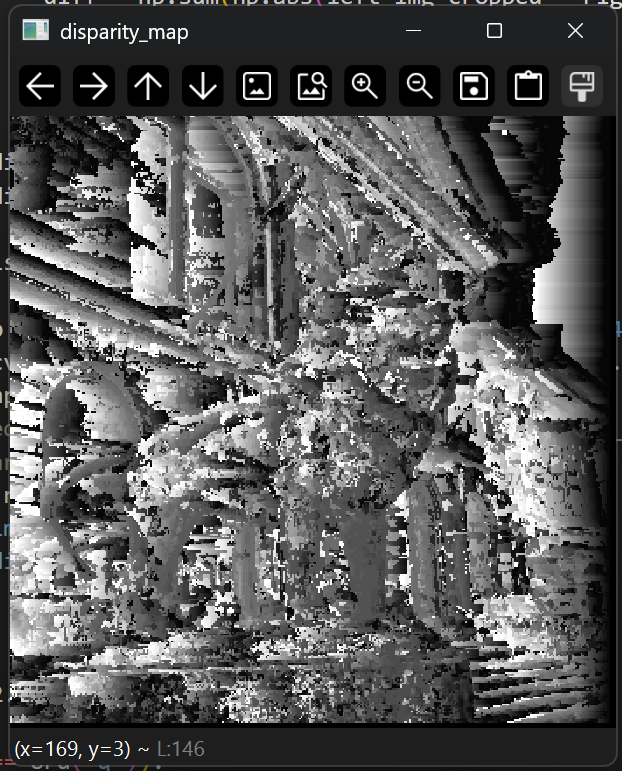